# Customer Fraud Detection – Binary Classification
**Dataset:** customer_analytics_dataset.csv  
**Target:** `is_fraudulent` (0 = Not Fraudulent, 1 = Fraudulent)  

**Pipeline:** Data → EDA → Preprocessing → Encoding → Train/Test Split → Scaling → SMOTE → Models → Evaluation → Best Model


In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Dataset

In [2]:
df = pd.read_csv('customer_analytics_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (5000, 13)


,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,2024-06-05,50,0.20
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.3,2024-02-19,37,0.34
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,NaN,2024-04-16,65,0.05
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.9,2020-07-08,93,0.19
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.3,2025-04-09,79,0.15


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   str    
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   str    
 3   country             5000 non-null   str    
 4   avg_order_value     4750 non-null   float64
 5   total_orders        5000 non-null   int64  
 6   last_purchase       5000 non-null   int64  
 7   is_fraudulent       5000 non-null   int64  
 8   preferred_category  5000 non-null   str    
 9   email_open_rate     4750 non-null   float64
 10  customer_since      5000 non-null   str    
 11  loyalty_score       5000 non-null   int64  
 12  churn_risk          5000 non-null   float64
dtypes: float64(3), int64(5), str(5)
memory usage: 507.9 KB


In [4]:
print("=== Statistical Summary ===")
display(df.describe())


=== Statistical Summary ===


,age,avg_order_value,total_orders,last_purchase,is_fraudulent,email_open_rate,loyalty_score,churn_risk
count,5000.000000,4750.000000,5000.000000,5000.000000,5000.000000,4750.000000,5000.000000,5000.000000
mean,48.163200,108.442857,10.027000,180.073200,0.025800,50.714842,50.039400,0.284484
std,17.880797,69.265559,3.163838,104.926518,0.158554,29.098706,28.832151,0.159690
min,18.000000,10.660000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,33.000000,57.805000,8.000000,89.000000,0.000000,25.225000,25.000000,0.160000
50%,48.000000,93.190000,10.000000,178.000000,0.000000,50.950000,50.000000,0.260000
75%,64.000000,142.197500,12.000000,270.000000,0.000000,76.800000,75.000000,0.390000
max,79.000000,555.460000,23.000000,364.000000,1.000000,100.000000,99.000000,0.900000


=== Missing Values ===
customer_id             0
age                     0
gender                  0
country                 0
avg_order_value       250
total_orders            0
last_purchase           0
is_fraudulent           0
preferred_category      0
email_open_rate       250
customer_since          0
loyalty_score           0
churn_risk              0
dtype: int64


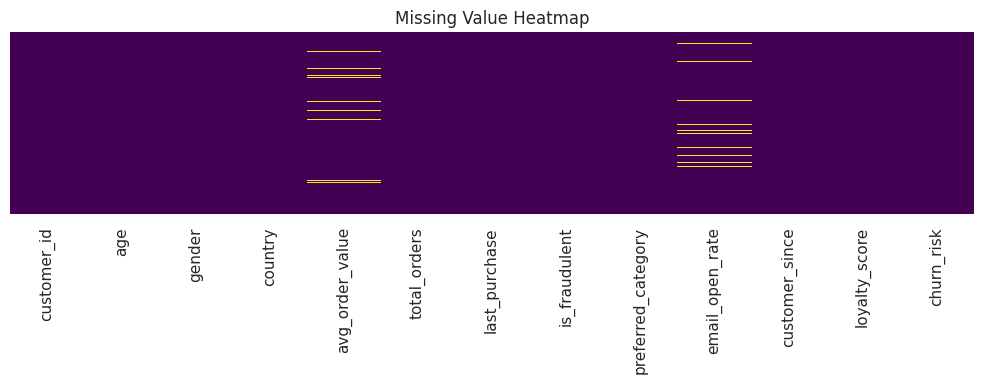

In [5]:
# ── Missing Values ─────────────────────────────────────────────────────────
print("=== Missing Values ===")
print(df.isnull().sum())

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()


Duplicate rows: 0

=== Target Class Distribution ===
is_fraudulent
0    4871
1     129
Name: count, dtype: int64

is_fraudulent
0    97.42 %
1     2.58 %
Name: proportion, dtype: str


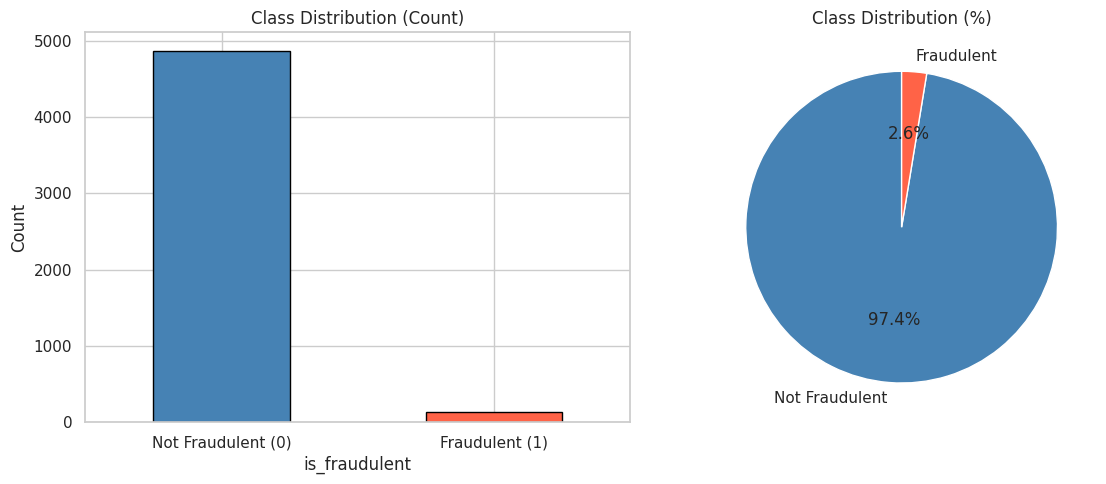

OBSERVATION: Dataset is HIGHLY IMBALANCED (~2.6% fraud). SMOTE will be applied.


In [6]:
# ── Duplicate Rows ──────────────────────────────────────────────────────────
print("Duplicate rows:", df.duplicated().sum())

# ── Target Class Distribution ───────────────────────────────────────────────
print()
print("=== Target Class Distribution ===")
print(df['is_fraudulent'].value_counts())
print()
pct = df['is_fraudulent'].value_counts(normalize=True).mul(100).round(2)
print(pct.astype(str) + ' %')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['is_fraudulent'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xticklabels(['Not Fraudulent (0)','Fraudulent (1)'], rotation=0)
axes[0].set_ylabel('Count')

df['is_fraudulent'].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['Not Fraudulent','Fraudulent'],
    autopct='%1.1f%%', colors=['steelblue','tomato'], startangle=90)
axes[1].set_title('Class Distribution (%)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

print("OBSERVATION: Dataset is HIGHLY IMBALANCED (~2.6% fraud). SMOTE will be applied.")


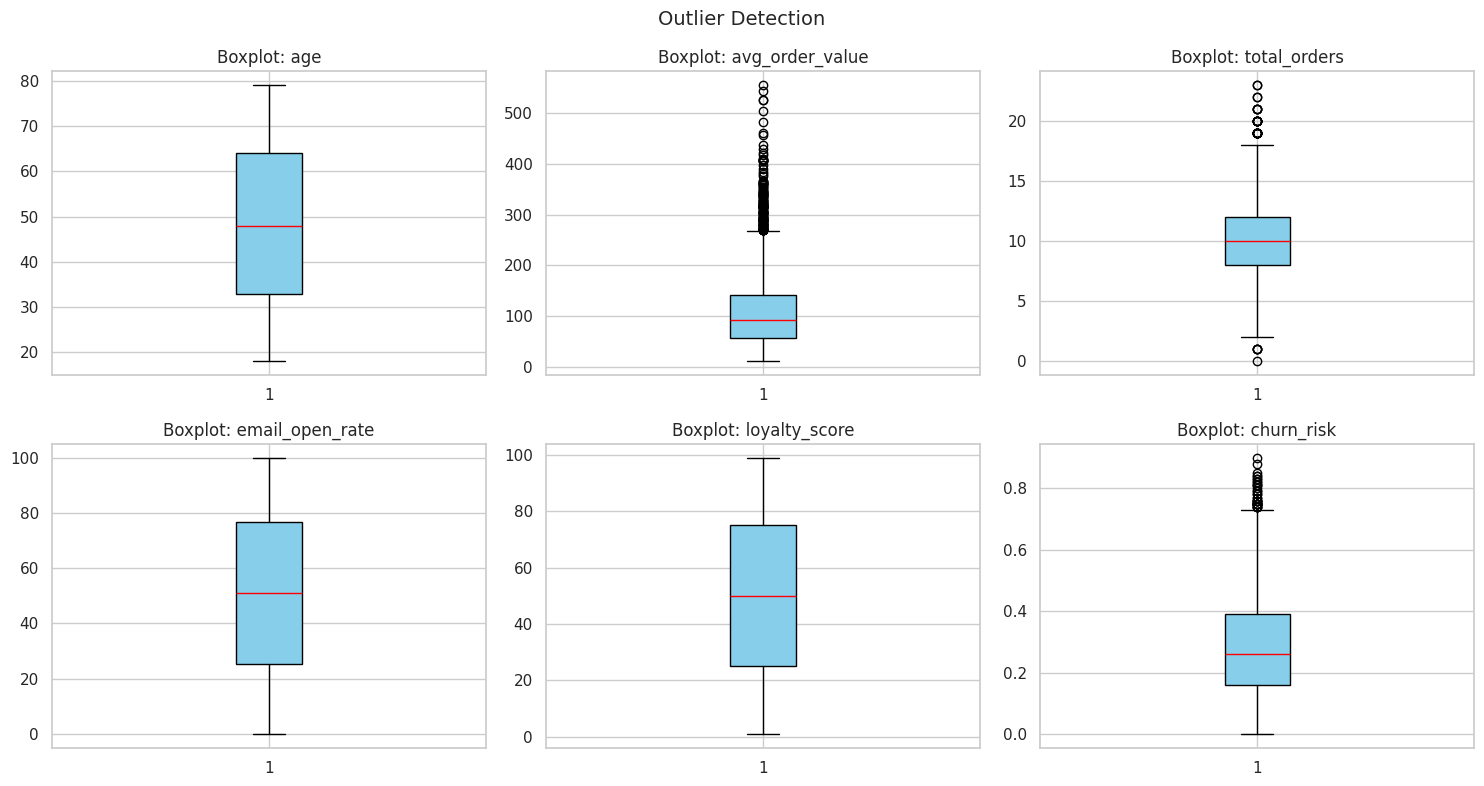

In [7]:
# ── Outlier Detection via Boxplots ─────────────────────────────────────────
numeric_cols = ['age','avg_order_value','total_orders',
                'email_open_rate','loyalty_score','churn_risk']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='skyblue'),
                    medianprops=dict(color='red'))
    axes[i].set_title(f'Boxplot: {col}')
plt.suptitle('Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()


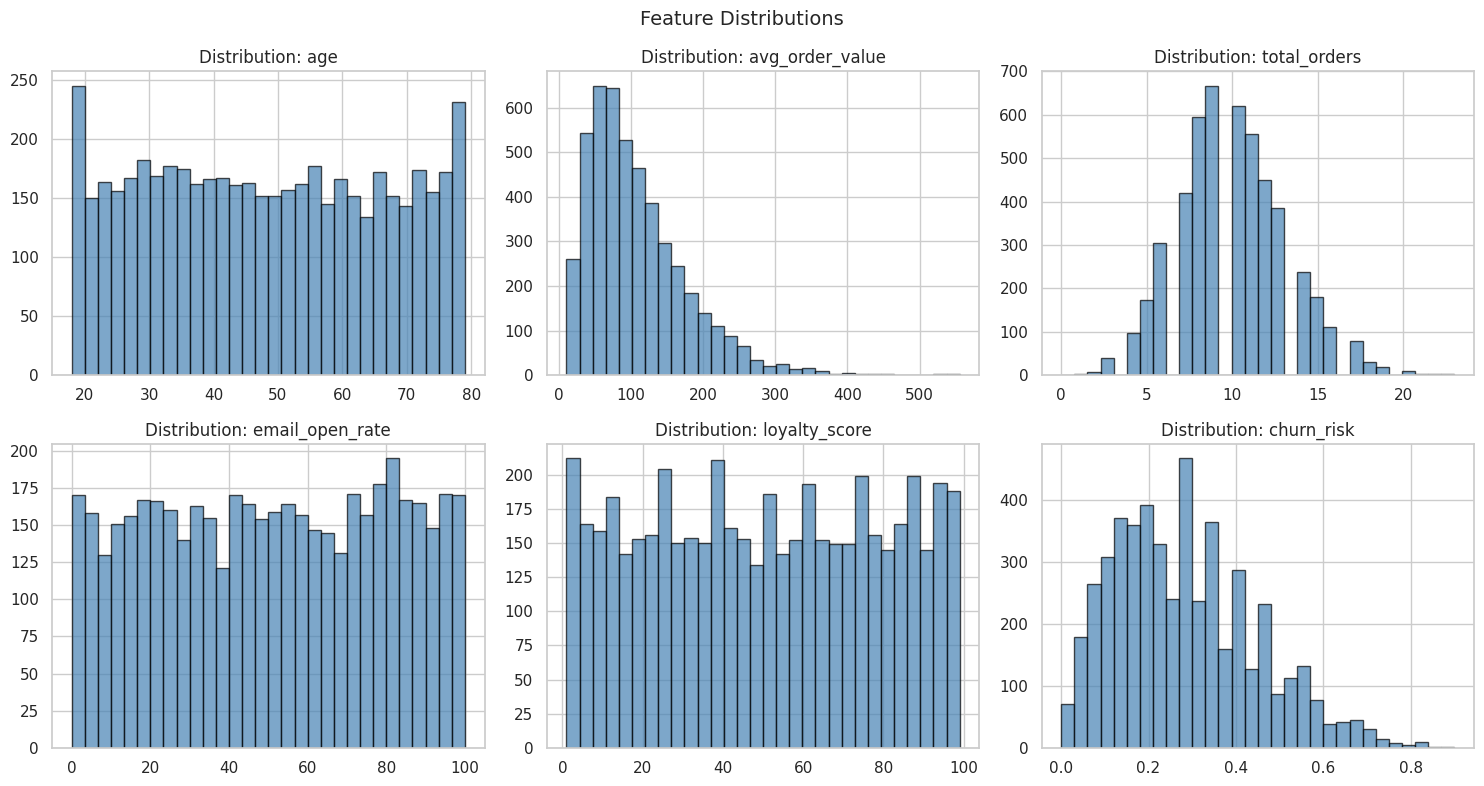

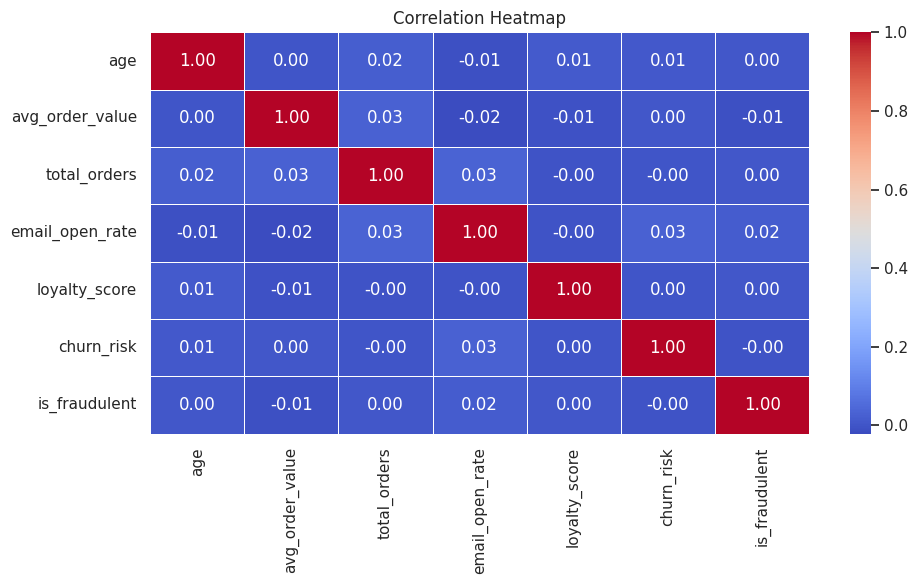

In [8]:
# ── Feature Distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30,
                 color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution: {col}')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# ── Correlation Heatmap ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
corr = df[numeric_cols + ['is_fraudulent']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


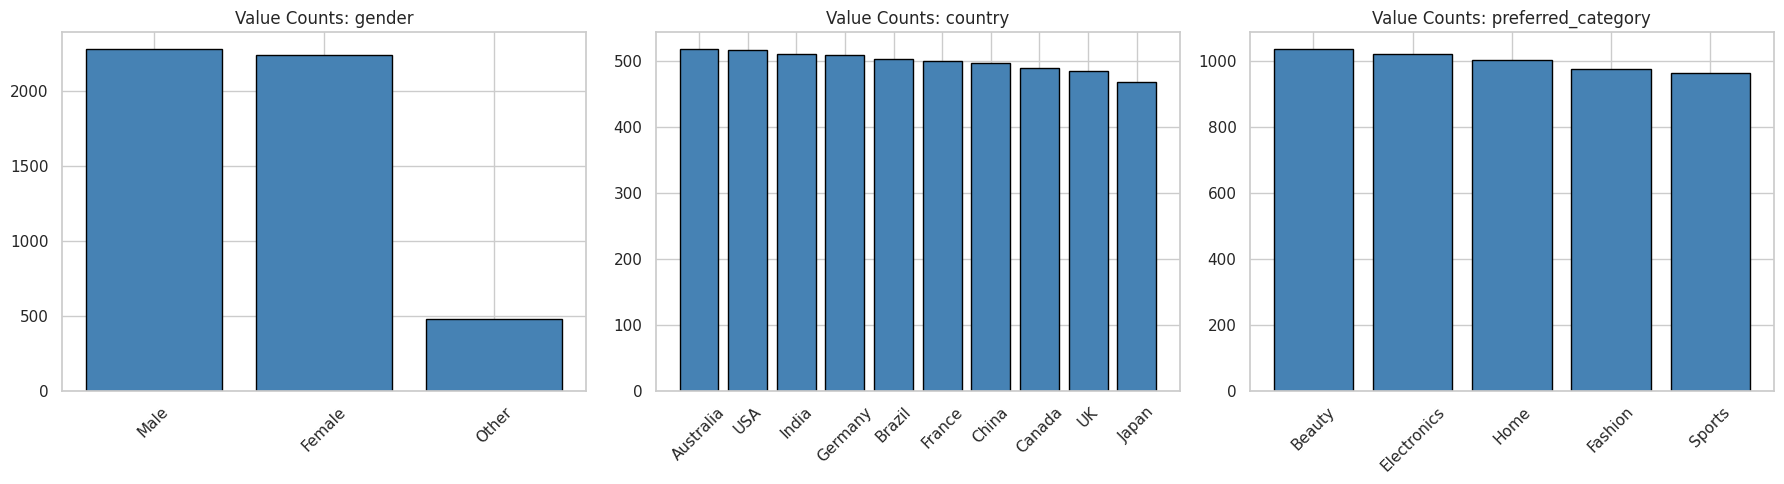

In [9]:
# ── Categorical Feature Counts ──────────────────────────────────────────────
cat_cols = ['gender','country','preferred_category']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Value Counts: {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing

In [10]:
# ── Drop customer_id (identifier only – not a feature) ─────────────────────
df = df.drop(columns=['customer_id'])
print("'customer_id' dropped. Columns:", df.shape[1])

# ── Impute Missing Values with Median (robust to outliers) ──────────────────
df['avg_order_value'] = df['avg_order_value'].fillna(df['avg_order_value'].median())
df['email_open_rate'] = df['email_open_rate'].fillna(df['email_open_rate'].median())
print("Missing values after imputation:", df.isnull().sum().sum())


'customer_id' dropped. Columns: 12
Missing values after imputation: 0


In [11]:
# ── Outlier Capping via IQR (Winsorization) ─────────────────────────────────
# Caps extreme values without removing rows – preserves all 5000 samples
for col in ['avg_order_value', 'total_orders', 'email_open_rate']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: {before} outliers capped → [{lower:.2f}, {upper:.2f}]")


avg_order_value: 169 outliers capped → [-59.31, 257.68]
total_orders: 42 outliers capped → [2.00, 18.00]
email_open_rate: 0 outliers capped → [-46.95, 148.65]


In [12]:
# ── Date Feature Engineering: customer_since ────────────────────────────────
df['customer_since'] = pd.to_datetime(df['customer_since'])
ref = pd.Timestamp('2025-01-01')   # fixed reference for reproducibility

df['customer_tenure_days'] = (ref - df['customer_since']).dt.days
df['customer_since_year']  = df['customer_since'].dt.year
df['customer_since_month'] = df['customer_since'].dt.month
df = df.drop(columns=['customer_since'])

print("Date features extracted:")
print(df[['customer_tenure_days','customer_since_year','customer_since_month']].head())


Date features extracted:
   customer_tenure_days  customer_since_year  customer_since_month
0                   210                 2024                     6
1                   317                 2024                     2
2                   260                 2024                     4
3                  1638                 2020                     7
4                   -98                 2025                     4


## 4. Encoding Categorical Features

| Column | Technique | Reason |
|--------|-----------|--------|
| `gender` | Label Encoding | 3 values, ordinal-friendly |
| `country` | One-Hot Encoding | Nominal – no inherent order |
| `preferred_category` | One-Hot Encoding | Nominal – no inherent order |


In [13]:
# Label Encode gender
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
print("Gender mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encode country and preferred_category
df = pd.get_dummies(df, columns=['country','preferred_category'], drop_first=True)

# Ensure no NaN after encoding
assert df.isnull().sum().sum() == 0, "NaN values detected after encoding!"
print(f"Encoding complete. Final shape: {df.shape}")
df.head(3)


Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Encoding complete. Final shape: (5000, 25)


,age,gender,avg_order_value,total_orders,last_purchase,is_fraudulent,email_open_rate,loyalty_score,churn_risk,customer_tenure_days,...,country_France,country_Germany,country_India,country_Japan,country_UK,country_USA,preferred_category_Electronics,preferred_category_Fashion,preferred_category_Home,preferred_category_Sports
0,30,0,101.08,8,176,1,25.60,50,0.20,210,...,False,False,False,False,False,False,False,False,False,False
1,53,0,90.39,10,88,0,12.30,37,0.34,317,...,False,False,False,False,False,True,True,False,False,False
2,73,1,83.28,6,203,0,50.95,65,0.05,260,...,False,False,False,False,False,False,False,False,False,True


## 5. Feature (X) and Target (y) Separation

In [14]:
X = df.drop(columns=['is_fraudulent'])
y = df['is_fraudulent']

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print()
print("Target distribution:")
print(y.value_counts())


Features shape: (5000, 24)
Target shape  : (5000,)

Target distribution:
is_fraudulent
0    4871
1     129
Name: count, dtype: int64


## 6. Train / Test Split (80 / 20, stratified)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Train class distribution:")
print(y_train.value_counts())


X_train: (4000, 24) | X_test: (1000, 24)
Train class distribution:
is_fraudulent
0    3897
1     103
Name: count, dtype: int64


## 7. Feature Scaling – StandardScaler

**Why StandardScaler (not MinMaxScaler)?**
- Standardizes each feature to mean = 0 and std = 1.
- Numeric features span very different ranges (age 18–79, avg_order_value 10–555+, tenure_days 0–1800+).
- StandardScaler is robust to capped outliers; MinMaxScaler would compress most values toward 0 if any extreme value exists.
- Fit only on training data → transform applied to both train and test to prevent data leakage.


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)          # transform test (no leakage)

print("Scaling done.")
print("Train mean (first 3 cols):", X_train_scaled[:, :3].mean(axis=0).round(4))
print("Train std  (first 3 cols):", X_train_scaled[:, :3].std(axis=0).round(4))


Scaling done.
Train mean (first 3 cols): [-0.  0. -0.]
Train std  (first 3 cols): [1. 1. 1.]


## 8. SMOTE – Class Balancing

**Required? YES.**
- Class 0 (Not Fraudulent): ~97.4% | Class 1 (Fraudulent): ~2.6%
- A model predicting all-0 would score 97% accuracy but detect ZERO fraud cases.
- SMOTE creates synthetic minority samples by interpolating between nearest neighbours.
- Applied **only on training data** to prevent leakage into the test set.


Before SMOTE: {0: np.int64(3897), 1: np.int64(103)}
After  SMOTE: {0: np.int64(3897), 1: np.int64(3897)}


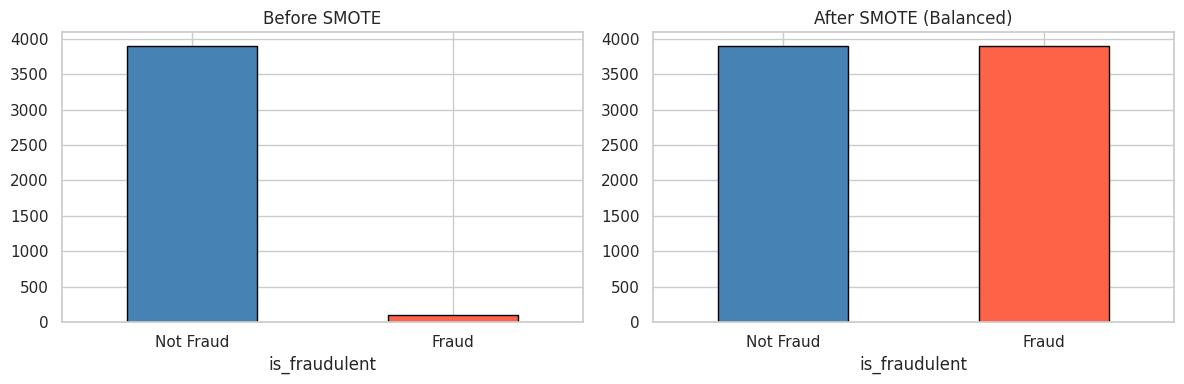

In [17]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", dict(pd.Series(y_train).value_counts()))
print("After  SMOTE:", dict(pd.Series(y_train_res).value_counts()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_xticklabels(['Not Fraud','Fraud'], rotation=0)

pd.Series(y_train_res).value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue','tomato'], edgecolor='black')
axes[1].set_title('After SMOTE (Balanced)')
axes[1].set_xticklabels(['Not Fraud','Fraud'], rotation=0)
plt.tight_layout()
plt.show()


## 9. Model Training & Evaluation

In [18]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, print full report, show confusion matrix, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    print(f"\n{'='*55}")
    print(f"  Model : {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred,
          target_names=['Not Fraudulent', 'Fraudulent']))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Fraud','Fraud'],
                yticklabels=['Not Fraud','Fraud'])
    plt.title(f'Confusion Matrix – {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {'Model': name, 'Accuracy': acc,
            'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results = []


### 9a. Decision Tree Classifier


  Model : Decision Tree
  Accuracy  : 0.7670
  Precision : 0.0230
  Recall    : 0.1923
  F1-Score  : 0.0412

Classification Report:
                precision    recall  f1-score   support

Not Fraudulent       0.97      0.78      0.87       974
    Fraudulent       0.02      0.19      0.04        26

      accuracy                           0.77      1000
     macro avg       0.50      0.49      0.45      1000
  weighted avg       0.95      0.77      0.85      1000



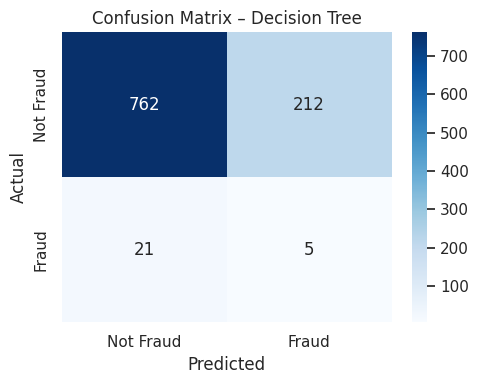

In [19]:
# max_depth=10 prevents overfitting; class_weight='balanced' extra safeguard
dt = DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced')
res_dt = evaluate_model('Decision Tree', dt,
                         X_train_res, y_train_res, X_test_scaled, y_test)
results.append(res_dt)


### 9b. Random Forest Classifier


  Model : Random Forest
  Accuracy  : 0.9730
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000

Classification Report:
                precision    recall  f1-score   support

Not Fraudulent       0.97      1.00      0.99       974
    Fraudulent       0.00      0.00      0.00        26

      accuracy                           0.97      1000
     macro avg       0.49      0.50      0.49      1000
  weighted avg       0.95      0.97      0.96      1000



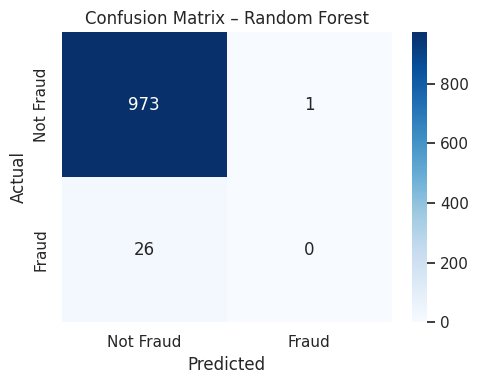

In [20]:
# Ensemble of 100 decision trees; reduces overfitting vs a single tree
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced', n_jobs=-1)
res_rf = evaluate_model('Random Forest', rf,
                         X_train_res, y_train_res, X_test_scaled, y_test)
results.append(res_rf)


### 9c. XGBoost Classifier


  Model : XGBoost
  Accuracy  : 0.9590
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000

Classification Report:
                precision    recall  f1-score   support

Not Fraudulent       0.97      0.98      0.98       974
    Fraudulent       0.00      0.00      0.00        26

      accuracy                           0.96      1000
     macro avg       0.49      0.49      0.49      1000
  weighted avg       0.95      0.96      0.95      1000



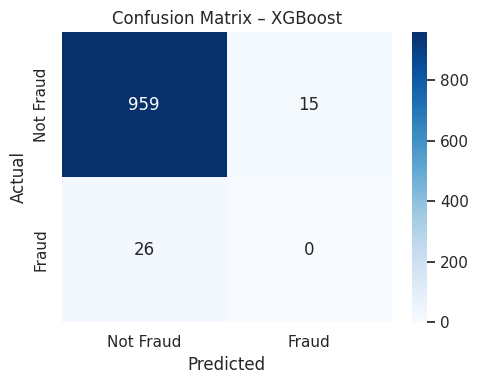

In [21]:
# scale_pos_weight re-weights minority class within XGBoost's loss function
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_wt  = neg_count / pos_count

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    scale_pos_weight=scale_wt,
                    eval_metric='logloss', n_jobs=-1, verbosity=0)
res_xgb = evaluate_model('XGBoost', xgb,
                          X_train_res, y_train_res, X_test_scaled, y_test)
results.append(res_xgb)


## 10. Model Comparison

In [22]:
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4).to_string())


               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree     0.767      0.023  0.1923    0.0412
Random Forest     0.973      0.000  0.0000    0.0000
XGBoost           0.959      0.000  0.0000    0.0000


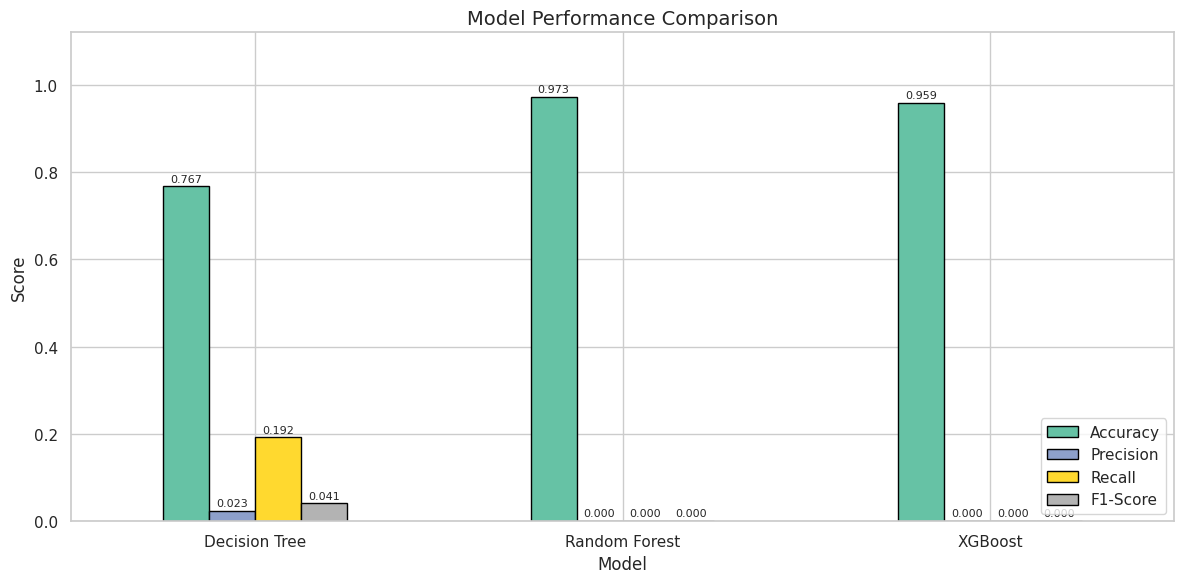

In [23]:
ax = results_df.plot(kind='bar', figsize=(12, 6),
                      edgecolor='black', colormap='Set2')
plt.title('Model Performance Comparison', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1.12)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()


## 11. Best Model Identification

In [24]:
best_name    = results_df['F1-Score'].idxmax()
best_metrics = results_df.loc[best_name]

print(f"{'='*52}")
print(f"  BEST MODEL : {best_name}")
print(f"{'='*52}")
print(f"  Accuracy  : {best_metrics['Accuracy']:.4f}")
print(f"  Precision : {best_metrics['Precision']:.4f}")
print(f"  Recall    : {best_metrics['Recall']:.4f}")
print(f"  F1-Score  : {best_metrics['F1-Score']:.4f}")
print()
print("NOTE: F1-Score is used as the primary metric for model selection.")
print("In fraud detection, Recall (catching real fraud) is critical.")
print("F1 balances both Precision and Recall, making it the right choice here.")


  BEST MODEL : Decision Tree
  Accuracy  : 0.7670
  Precision : 0.0230
  Recall    : 0.1923
  F1-Score  : 0.0412

NOTE: F1-Score is used as the primary metric for model selection.
In fraud detection, Recall (catching real fraud) is critical.
F1 balances both Precision and Recall, making it the right choice here.


## 12. Final Summary

| Step | Decision | Reason |
|------|----------|--------|
| **customer_id** | Dropped | Identifier only – not a predictive feature |
| **Missing Values** | Median imputation | Robust to outliers; keeps all 5000 rows |
| **Outliers** | IQR capping (Winsorization) | Limits extreme values without data loss |
| **Date Feature** | Extracted tenure_days, year, month | Converts raw date into usable numeric features |
| **Encoding** | Label Encoding (gender), One-Hot (country, preferred_category) | Match each column's nature (ordinal vs nominal) |
| **Scaling** | StandardScaler | Equalises feature magnitudes; robust post-capping |
| **SMOTE** | YES – training data only | Severe imbalance (~2.6% fraud) demands balancing |
| **Decision Tree** | Applied | Interpretable baseline |
| **Random Forest** | Applied | Ensemble; better generalisation than single tree |
| **XGBoost** | Applied | Gradient boosting; top performer on tabular data |
| **Best Model** | Selected by F1-Score | Balances Precision & Recall for imbalanced fraud data |

**Key Insight:** In fraud detection, Accuracy alone is misleading.  
A naive all-zero model achieves ~97% accuracy but catches **zero fraud cases**.  
**Recall and F1-Score** are the metrics that truly matter here.
